# Github Connectivity project

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

G = nx.read_gexf('exploration_state.gexf')

print(f"Network loaded successfully!")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Network loaded successfully!
Nodes: 48951
Edges: 2279238


In [3]:
density = nx.density(G)
print(f"Network density: {density:.4f}")

avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Average clustering coefficient: {avg_clustering:.4f}")

Network density: 0.0019
Average clustering coefficient: 0.9201


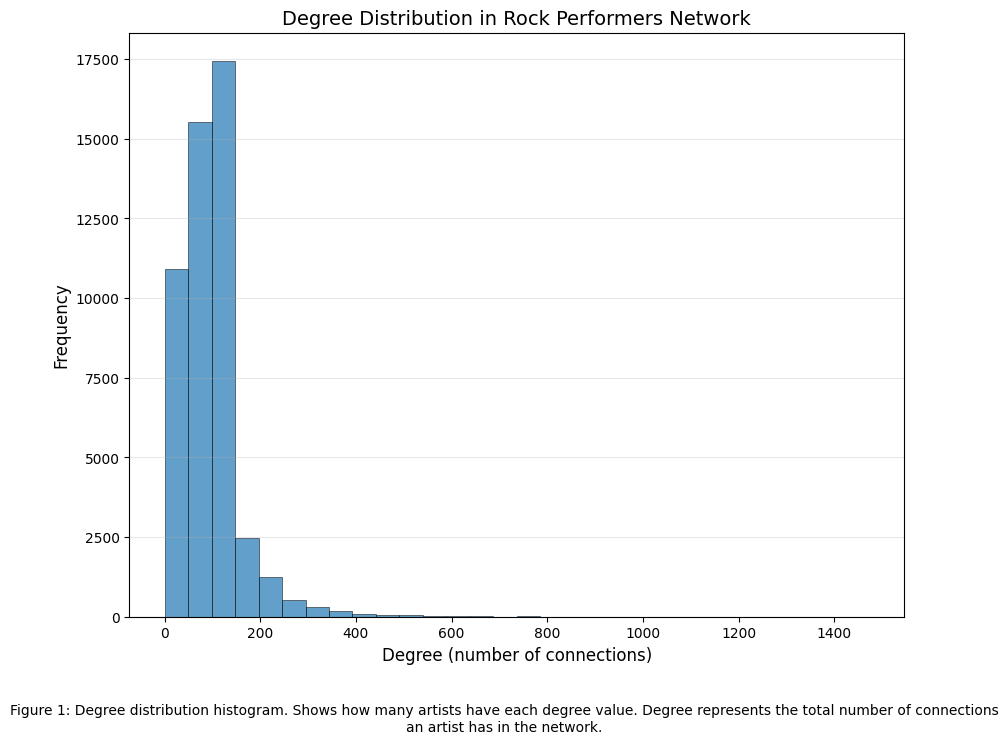


Degree statistics:
Average degree: 93.12
Median degree: 98.00
Max degree: 1473
Min degree: 0


In [5]:
# Get degrees for all nodes (undirected graph)
degrees = [G.degree(node) for node in G.nodes()]

# Create histogram or degree distribution plot
plt.figure(figsize=(10, 8))
plt.hist(degrees, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.xlabel('Degree (number of connections)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Degree Distribution in Rock Performers Network', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

plt.figtext(0.5, 0.01, "Figure 1: Degree distribution histogram. Shows how many artists have each degree value. " \
"Degree represents the total number of connections an artist has in the network.", 
ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Print some statistics
print(f"\nDegree statistics:")
print(f"Average degree: {np.mean(degrees):.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")

In [8]:
G_undirected = G
assortativity = nx.degree_assortativity_coefficient(G_undirected)
print(f"Degree Assortativity Coefficient: {assortativity:.4f}")

Degree Assortativity Coefficient: 0.1330


In [12]:
# NetworkX doesn't have built-in parallel support, but you can use this workaround
import networkx as nx
from joblib import Parallel, delayed
import numpy as np

def compute_ebc_chunk(G, sample_nodes):
    """Compute edge betweenness for a chunk of sampled nodes"""
    return nx.edge_betweenness_centrality_subset(
        G, 
        sources=sample_nodes, 
        targets=G.nodes()
    )

# Sample 20K nodes and split into 12 chunks
k = 20000
n_jobs = 12
sampled_nodes = np.random.choice(list(G.nodes()), k, replace=False)
chunks = np.array_split(sampled_nodes, n_jobs)

# Compute in parallel
results = Parallel(n_jobs=n_jobs)(
    delayed(compute_ebc_chunk)(G, chunk.tolist()) 
    for chunk in chunks
)

# Combine results
ebc = {}
for result in results:
    for edge, value in result.items():
        ebc[edge] = ebc.get(edge, 0) + value

print(f"Computed edge betweenness using {k} sampled nodes across {n_jobs} jobs")

Computed edge betweenness using 20000 sampled nodes across 12 jobs


In [29]:
def disparity_filter(G, alpha=0.135):
    """
    Apply disparity filter to extract network backbone.
    
    For each node, the disparity filter tests whether each edge weight
    is significantly larger than expected under a null model.
    """
    B = nx.Graph()
    B.add_nodes_from(G.nodes(data=True))
    
    for node in G.nodes():
        edges = list(G.edges(node, data=True))
        
        if len(edges) == 0:
            continue
            
        k = len(edges)  # degree
        s = sum(d.get('weight', 1) for u, v, d in edges)  # total strength
        
        for u, v, data in edges:
            weight = data.get('weight', 1)
            
            if s > 0:
                # Disparity filter p-value
                p_value = (1 - weight / s) ** (k - 1)
                
                if p_value < alpha:
                    if not B.has_edge(u, v):
                        B.add_edge(u, v, weight=weight, p_value=p_value)
    
    return B

# Create weighted graph from your original graph G
# Use the computed edge betweenness as weights
G_weighted = G.copy()
for edge, betweenness in ebc.items():
    if G_weighted.has_edge(edge[0], edge[1]):
        G_weighted[edge[0]][edge[1]]['weight'] = betweenness

# Now apply the disparity filter
backbone = disparity_filter(G_weighted, alpha=0.000135)
# Remove isolated nodes
isolated = [node for node in backbone.nodes() if backbone.degree(node) == 0]
backbone.remove_nodes_from(isolated)

# Report statistics
print(f"\nBackbone Statistics:")
print(f"  Nodes: {backbone.number_of_nodes()} ({100*backbone.number_of_nodes()/G.number_of_nodes():.1f}% of original)")
print(f"  Edges: {backbone.number_of_edges()} ({100*backbone.number_of_edges()/G_weighted.number_of_edges():.1f}% of original)")
print(f"  Density: {nx.density(backbone):.4f} (original: {nx.density(G_weighted):.4f})")


Backbone Statistics:
  Nodes: 44773 (91.5% of original)
  Edges: 113414 (5.0% of original)
  Density: 0.0001 (original: 0.0019)


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

top_5_degree = top_degree[:5]
artists_deg = [artist for artist, _ in top_5_degree]
values_deg = [val for _, val in top_5_degree]
axs[0].barh(artists_deg, values_deg, color='steelblue')
axs[0].set_xlabel('Degree Centrality', fontsize=11)
axs[0].set_title('Top 5 by Degree Centrality', fontsize=12)
axs[0].invert_yaxis()

top_5_bet = top_betweenness[:5]
artists_bet = [artist for artist, _ in top_5_bet]
values_bet = [val for _, val in top_5_bet]
axs[1].barh(artists_bet, values_bet, color='coral')
axs[1].set_xlabel('Betweenness Centrality', fontsize=11)
axs[1].set_title('Top 5 by Betweenness Centrality', fontsize=12)
axs[1].invert_yaxis()

top_5_close = top_closeness[:5]
artists_close = [artist for artist, _ in top_5_close]
values_close = [val for _, val in top_5_close]
axs[2].barh(artists_close, values_close, color='lightgreen')
axs[2].set_xlabel('Closeness Centrality', fontsize=11)
axs[2].set_title('Top 5 by Closeness Centrality', fontsize=12)
axs[2].invert_yaxis()

plt.figtext(0.5, 0.01, "Figure 2: Top 5 artists by three different centrality measures. " \
            "Different measures reveal different types of importance in the network.",
            ha="center", fontsize=10, wrap=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

In [ ]:
import networkx as nx

def shortest_path_between_users(G, source_user, target_user):
    """
    Find the shortest path (in hops) from source_user to target_user.

    Parameters:
        G (nx.Graph): The GitHub collaboration graph.
        source_user (str): Starting username.
        target_user (str): Target username.

    Returns:
        path (list): List of users from source_user to target_user.
    """
    if source_user not in G:
        raise ValueError(f"User '{source_user}' not found in graph")

    if target_user not in G:
        raise ValueError(f"User '{target_user}' not found in graph")

    try:
        path = nx.shortest_path(G, source=source_user, target=target_user)
        return path
    except nx.NetworkXNoPath:
        raise nx.NetworkXNoPath(
            f"No path found from '{source_user}' to '{target_user}'"
        )

In [ ]:
# Visualize the backbone using NetworkX spring layout
plt.figure(figsize=(10, 10))

pos = nx.kamada_kawai_layout(backbone)  # Usually faster, deterministic

# Node sizes and colors based on degree in backbone
node_sizes = [backbone.degree(node) * 30 for node in backbone.nodes()]
node_colors = [backbone.degree(node) for node in backbone.nodes()]

nx.draw_networkx_nodes(backbone, pos, node_size=node_sizes, node_color=node_colors,
                       cmap=plt.cm.YlOrRd, alpha=0.7, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(backbone, pos, alpha=0.2, width=0.5)

high_degree_nodes = [node for node in backbone.nodes() 
                     if backbone.degree(node) > np.percentile([backbone.degree(n) for n in backbone.nodes()], 85)]
labels = {node: node for node in high_degree_nodes}
nx.draw_networkx_labels(backbone, pos, labels, font_size=9, font_weight='bold')

plt.title(f'Rock Performers Network Backbone (α = 0.135)\n{backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges',
          fontsize=16)
plt.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, 
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Degree', rotation=270, labelpad=20)

plt.figtext(0.5, 0.01, "Figure 5: Network backbone visualization using spring layout. Node size and color represent degree. " \
            "Labels shown for high-degree nodes (top 15%).",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.08)
plt.show()